# 📊 YouTube Channel Performance Analytics
### Unlocking YouTube Channel Performance Secrets — ML Analysis
---
**Dataset:** 364 videos × 70 features | Revenue, Engagement, Audience & Ad metrics

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

import isodate

# Plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


## Step 2 — Load and Explore the Dataset

In [2]:
data = pd.read_csv("/mnt/user-data/uploads/youtube_channel_real_performance_analytics.csv")

print(f"Dataset shape: {data.shape[0]} rows × {data.shape[1]} columns")
print("\n--- Column Info ---")
print(data.info())

Dataset shape: 364 rows × 70 columns

--- Column Info ---
<class 'pandas.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 70 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ID                                  364 non-null    int64  
 1   Video Duration                      364 non-null    float64
 2   Video Publish Time                  364 non-null    str    
 3   Days Since Publish                  364 non-null    int64  
 4   Day                                 364 non-null    int64  
 5   Month                               364 non-null    int64  
 6   Year                                364 non-null    int64  
 7   Day of Week                         364 non-null    str    
 8   Revenue per 1000 Views (USD)        364 non-null    float64
 9   Monetized Playbacks (Estimate)      364 non-null    float64
 10  Playback-Based CPM (USD)            364 non-null    float64
 11

In [3]:
print("--- Missing Values ---")
missing = data.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "✅ No missing values found!")
print(f"\nTotal nulls: {data.isnull().sum().sum()}")

--- Missing Values ---
✅ No missing values found!

Total nulls: 0


In [4]:
print("--- First 5 Rows ---")
data.head()

--- First 5 Rows ---


,ID,Video Duration,Video Publish Time,Days Since Publish,Day,Month,Year,Day of Week,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
0,0,201.0,2016-06-02 00:00:00,0,2,6,2016,Thursday,0.024,723.0,...,0.0,0.0,40.38,81.0,23531.0,533.1636,51.0,0.561,41118.0,27.66
1,1,391.0,2016-06-10 00:00:00,8,10,6,2016,Friday,0.056,727.0,...,0.0,0.0,39.85,156.0,11478.0,500.5628,33.0,0.648,41627.0,5.85
2,2,133.0,2016-06-14 00:00:00,4,14,6,2016,Tuesday,0.014,76.0,...,0.0,0.0,30.88,41.0,6153.0,70.7287,8.0,0.089,38713.0,7.07
3,3,14.0,2016-06-29 00:00:00,15,29,6,2016,Wednesday,0.004,18.0,...,0.0,0.0,103.05,14.0,4398.0,17.6251,2.0,0.017,35245.0,5.60
4,4,45.0,2016-07-01 00:00:00,2,1,7,2016,Friday,0.000,0.0,...,0.0,0.0,55.70,25.0,14659.0,104.3341,28.0,0.000,46218.0,8.62


In [5]:
print("--- Statistical Summary ---")
data.describe().round(2)

--- Statistical Summary ---


,ID,Video Duration,Days Since Publish,Day,Month,Year,Revenue per 1000 Views (USD),Monetized Playbacks (Estimate),Playback-Based CPM (USD),CPM (USD),...,Watched (Not Skipped) (%),Feed Impressions,Average View Percentage (%),Average View Duration,Views,Watch Time (hours),Subscribers,Estimated Revenue (USD),Impressions,Video Thumbnail CTR (%)
count,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00,...,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00,364.00
mean,181.50,664.24,8.41,15.81,6.64,2018.74,0.11,8934.71,1.55,1.06,...,0.82,0.01,45.97,285.61,128800.10,10058.97,321.02,8.85,959528.62,7.91
std,105.22,330.65,15.37,8.92,3.42,2.53,0.18,12967.84,1.08,0.73,...,9.05,0.09,12.46,116.60,118209.84,9516.16,444.59,13.41,1180519.11,2.90
min,0.00,9.00,0.00,1.00,1.00,2016.00,0.00,0.00,0.00,0.00,...,0.00,0.00,15.05,8.00,2461.00,12.70,-3.00,0.00,32228.00,0.62
25%,90.75,496.00,3.00,8.00,4.00,2017.00,0.02,349.50,0.82,0.52,...,0.00,0.00,40.25,233.75,27160.50,2759.40,41.00,0.44,131708.25,6.42
50%,181.50,613.00,5.00,16.00,7.00,2018.00,0.05,3564.00,1.54,1.16,...,0.00,0.00,45.46,286.50,101950.50,8102.96,180.00,4.28,620406.50,8.40
75%,272.25,786.50,9.00,23.00,10.00,2021.00,0.14,13579.25,2.03,1.46,...,0.00,0.00,51.01,344.25,198169.50,14084.50,421.25,11.48,1368463.75,9.92
max,363.00,2311.00,260.00,31.00,12.00,2024.00,1.60,100566.00,7.38,6.30,...,100.00,1.00,117.30,776.00,670990.00,53794.66,3728.00,103.12,12702263.00,27.66


## Step 3 — Data Cleaning

In [6]:
print(f"Rows before cleaning: {len(data)}")
data = data.dropna()
print(f"Rows after dropna: {len(data)}")

# Video Duration is already in seconds (float) – confirm
print(f"\nVideo Duration dtype: {data['Video Duration'].dtype}")
print(f"Sample durations (seconds): {data['Video Duration'].head().values}")
print("✅ Duration already in seconds – no ISO-8601 conversion needed.")

Rows before cleaning: 364
Rows after dropna: 364

Video Duration dtype: float64
Sample durations (seconds): [201. 391. 133.  14.  45.]
✅ Duration already in seconds – no ISO-8601 conversion needed.


In [7]:
# Rename the YouTube Premium column (has non-breaking space)
data.rename(columns={
    'YouTube\xa0Premium (USD)': 'YouTube Premium (USD)'
}, inplace=True)

# Parse publish time
data['Video Publish Time'] = pd.to_datetime(data['Video Publish Time'], errors='coerce')
print("Video Publish Time sample:")
print(data['Video Publish Time'].head())

# Duration buckets
data['Duration_Bucket'] = pd.cut(
    data['Video Duration'],
    bins=[0, 60, 300, 600, 1200, np.inf],
    labels=['<1 min', '1-5 min', '5-10 min', '10-20 min', '20+ min']
)
print("\nDuration Bucket distribution:")
print(data['Duration_Bucket'].value_counts())

Video Publish Time sample:
0   2016-06-02
1   2016-06-10
2   2016-06-14
3   2016-06-29
4   2016-07-01
Name: Video Publish Time, dtype: datetime64[us]

Duration Bucket distribution:
Duration_Bucket
10-20 min    167
5-10 min     148
20+ min       22
1-5 min       15
<1 min        12
Name: count, dtype: int64


## Step 4 — Exploratory Data Analysis (EDA)

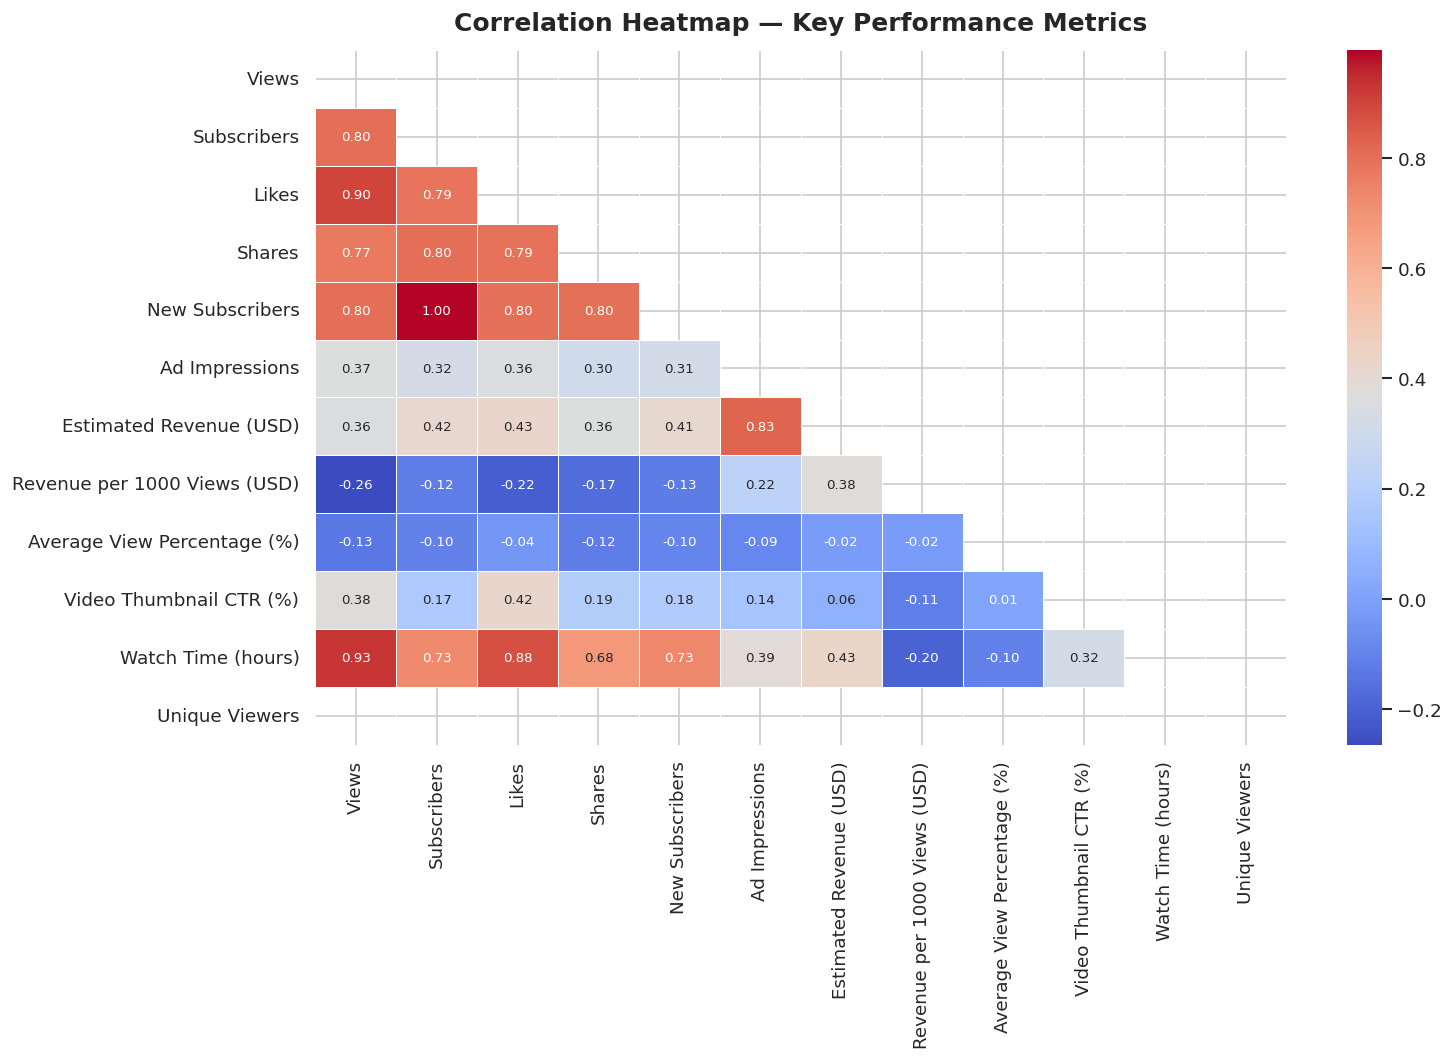

Highest correlation with Estimated Revenue:
Ad Impressions        0.825534
Watch Time (hours)    0.431998
Likes                 0.425544
Subscribers           0.418177
New Subscribers       0.412932
Name: Estimated Revenue (USD), dtype: float64


In [8]:
# --- Correlation Heatmap ---
key_cols = [
    'Views', 'Subscribers', 'Likes', 'Shares', 'New Subscribers',
    'Ad Impressions', 'Estimated Revenue (USD)', 'Revenue per 1000 Views (USD)',
    'Average View Percentage (%)', 'Video Thumbnail CTR (%)',
    'Watch Time (hours)', 'Unique Viewers'
]
corr = data[key_cols].corr()

fig, ax = plt.subplots(figsize=(13, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title("Correlation Heatmap — Key Performance Metrics", fontsize=15, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('/home/claude/fig_heatmap.png', bbox_inches='tight')
plt.show()
print("Highest correlation with Estimated Revenue:")
print(corr['Estimated Revenue (USD)'].drop('Estimated Revenue (USD)').sort_values(ascending=False).head(5))

In [9]:
# --- Top 10 Videos by Revenue ---
top_videos = data.sort_values('Estimated Revenue (USD)', ascending=False).head(10)
print("Top 10 Videos by Estimated Revenue:")
print(top_videos[['ID', 'Estimated Revenue (USD)', 'Views', 'Subscribers',
                   'Average View Percentage (%)']].to_string(index=False))

Top 10 Videos by Estimated Revenue:
 ID  Estimated Revenue (USD)    Views  Subscribers  Average View Percentage (%)
228                  103.117 670990.0       3538.0                        42.11
257                   83.979 241060.0       1125.0                        37.51
251                   80.265 343319.0       1437.0                        47.68
289                   70.247  99196.0        350.0                        55.36
278                   65.978 188324.0       1824.0                        55.11
260                   62.047 302999.0        866.0                        41.09
293                   59.058 101025.0        602.0                        50.96
294                   55.040  67556.0        581.0                        52.30
290                   50.344  89284.0        995.0                        60.93
284                   44.228  93487.0        305.0                        51.14


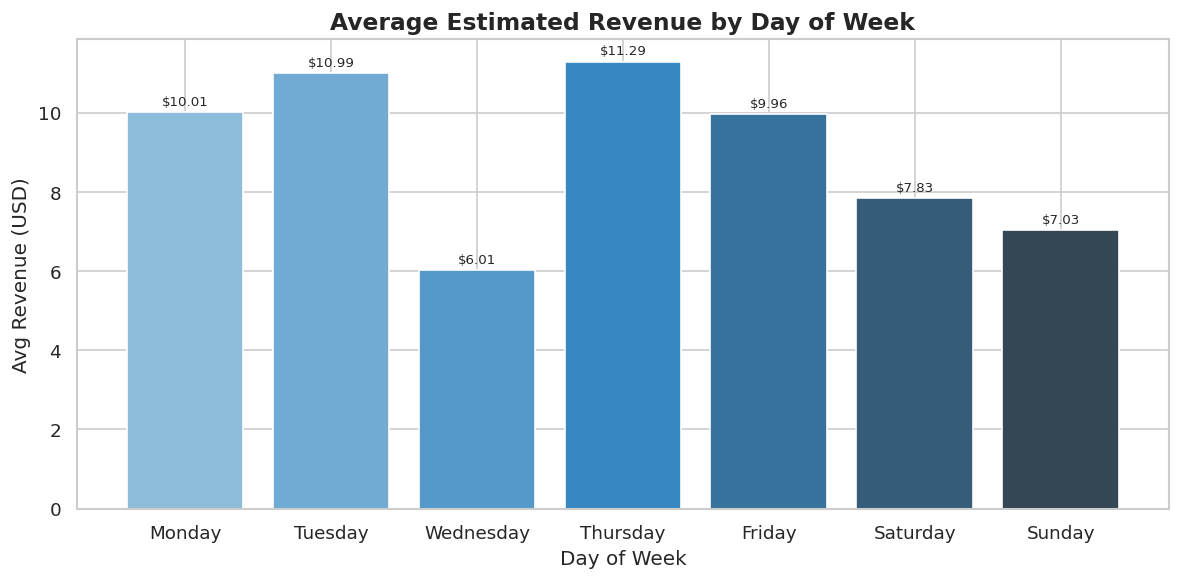

In [10]:
# --- Revenue by Day of Week ---
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_rev = data.groupby('Day of Week')['Estimated Revenue (USD)'].mean().reindex(day_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(dow_rev.index, dow_rev.values, color=sns.color_palette('Blues_d', 7))
ax.set_title("Average Estimated Revenue by Day of Week", fontsize=14, fontweight='bold')
ax.set_xlabel("Day of Week"); ax.set_ylabel("Avg Revenue (USD)")
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f"${bar.get_height():.2f}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('/home/claude/fig_dow.png', bbox_inches='tight')
plt.show()

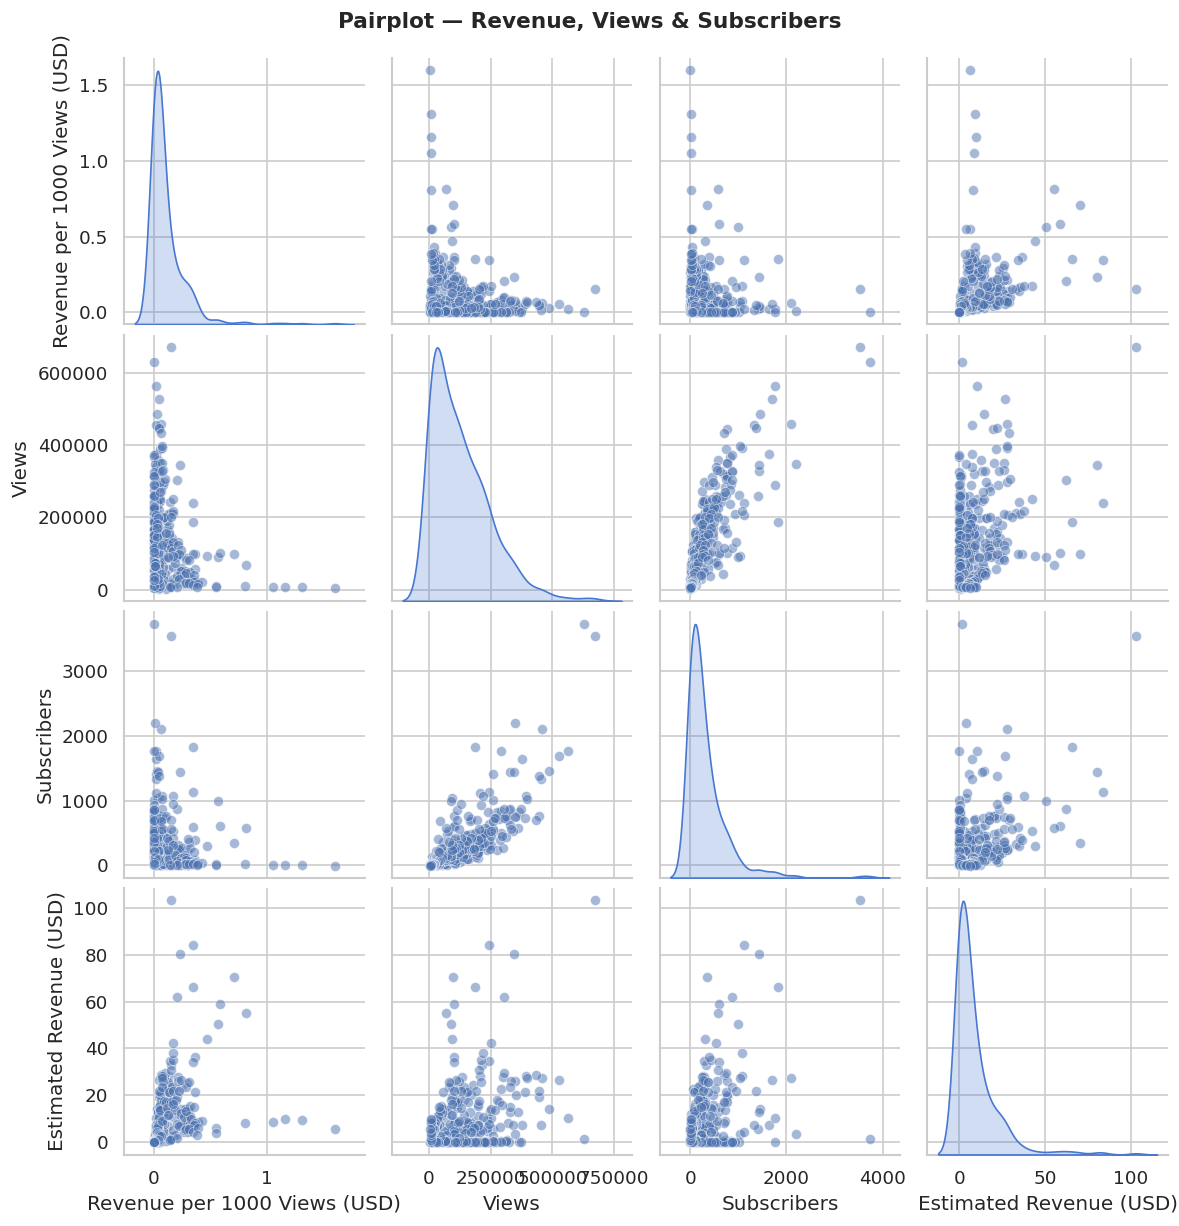

In [11]:
# --- Pairplot ---
pair_cols = ['Revenue per 1000 Views (USD)', 'Views', 'Subscribers', 'Estimated Revenue (USD)']
pair_df = data[pair_cols].copy()
g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.5, 'color': '#4C72B0'})
g.fig.suptitle("Pairplot — Revenue, Views & Subscribers", y=1.02, fontsize=13, fontweight='bold')
plt.savefig('/home/claude/fig_pairplot.png', bbox_inches='tight')
plt.show()

## Step 5 — Feature Engineering

In [12]:
# Revenue per view
data['Revenue_per_View'] = data['Estimated Revenue (USD)'] / data['Views'].replace(0, np.nan)

# Engagement rate
data['Engagement_Rate'] = (
    (data['Likes'] + data['Shares'] + data['New Comments']) /
    data['Views'].replace(0, np.nan)
) * 100

# CTR score (combined impressions & thumbnail CTR)
data['CTR_Score'] = data['Video Thumbnail CTR (%)'] * np.log1p(data['Impressions'])

# Subscriber efficiency
data['Sub_Efficiency'] = data['New Subscribers'] / data['Views'].replace(0, np.nan) * 1000

print("✅ New features created:")
print(data[['Revenue_per_View','Engagement_Rate','CTR_Score','Sub_Efficiency']].describe().round(4))

✅ New features created:
       Revenue_per_View  Engagement_Rate  CTR_Score  Sub_Efficiency
count          364.0000         364.0000   364.0000        364.0000
mean             0.0001           5.4432   105.0997          2.5365
std              0.0002           2.1381    41.2388          2.1756
min              0.0000           2.3511     6.6242          0.0000
25%              0.0000           3.9069    82.4721          1.3325
50%              0.0001           4.9512   114.5503          2.0437
75%              0.0001           6.6277   136.3811          2.9382
max              0.0015          13.4227   293.8661         18.3686


## Step 6 — Data Visualizations

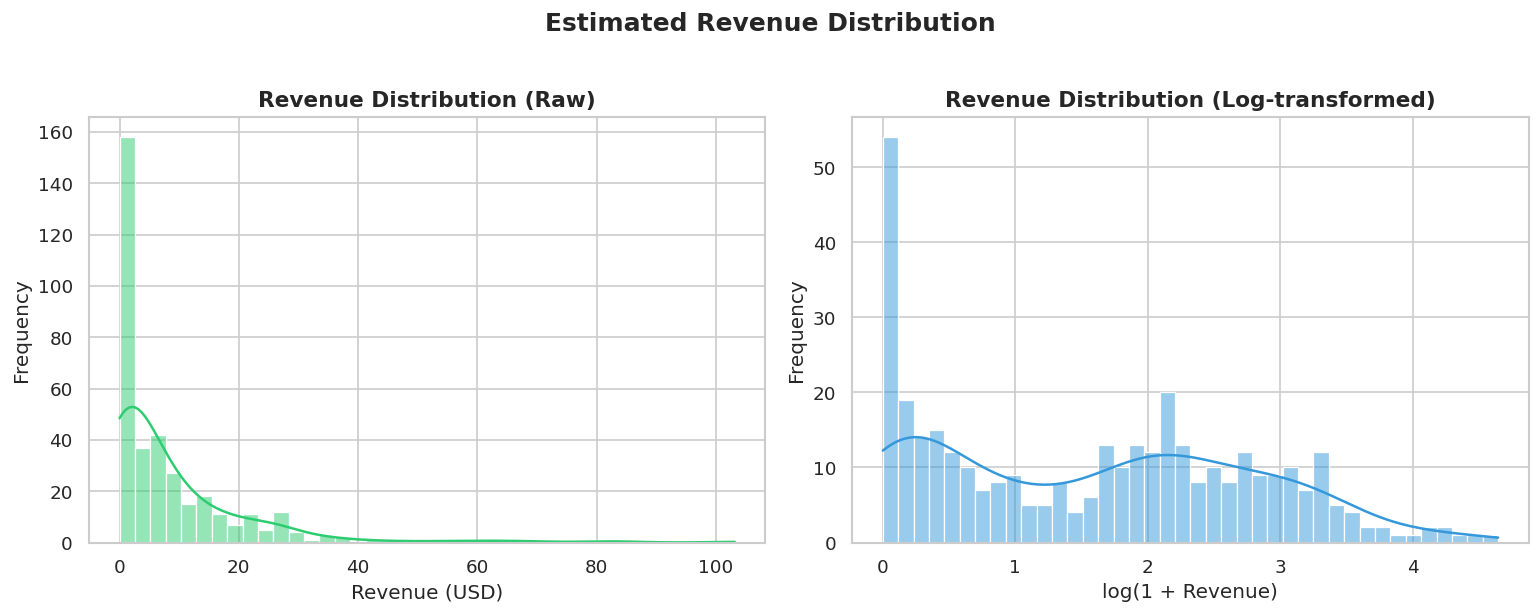

In [13]:
# --- Revenue Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.histplot(data['Estimated Revenue (USD)'], bins=40, kde=True, color='#2ecc71', ax=axes[0])
axes[0].set_title("Revenue Distribution (Raw)", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Revenue (USD)"); axes[0].set_ylabel("Frequency")

log_rev = np.log1p(data['Estimated Revenue (USD)'])
sns.histplot(log_rev, bins=40, kde=True, color='#3498db', ax=axes[1])
axes[1].set_title("Revenue Distribution (Log-transformed)", fontsize=13, fontweight='bold')
axes[1].set_xlabel("log(1 + Revenue)"); axes[1].set_ylabel("Frequency")

plt.suptitle("Estimated Revenue Distribution", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/fig_rev_dist.png', bbox_inches='tight')
plt.show()

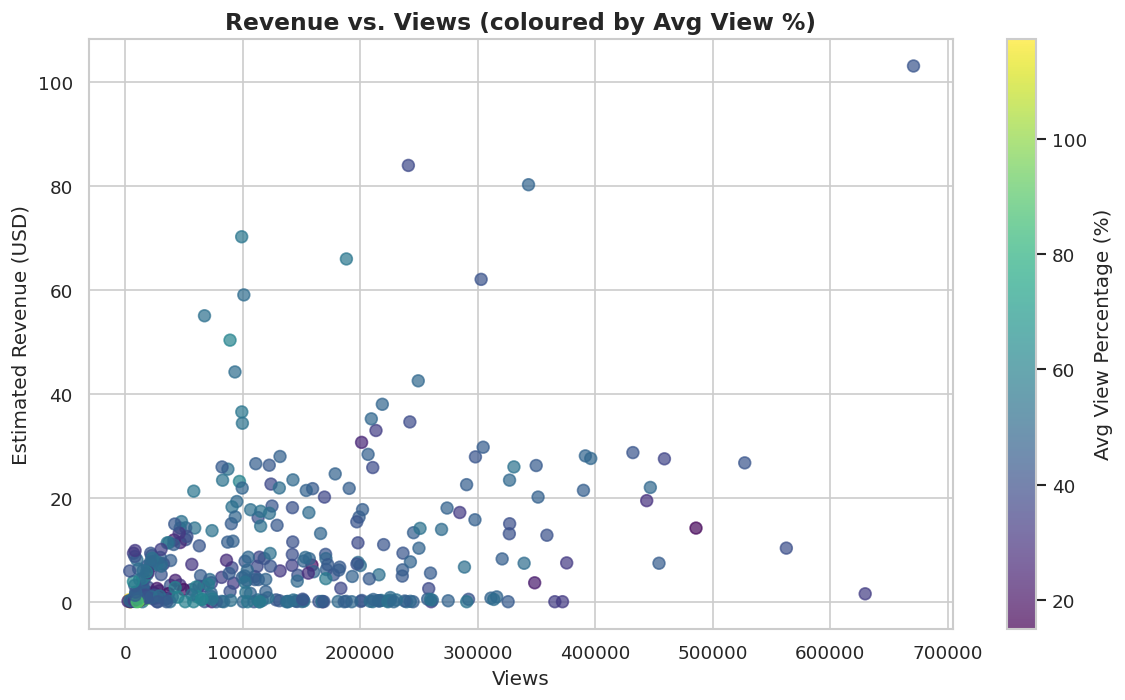

In [14]:
# --- Revenue vs Views ---
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(data['Views'], data['Estimated Revenue (USD)'],
                c=data['Average View Percentage (%)'], cmap='viridis', alpha=0.7, s=50)
plt.colorbar(sc, ax=ax, label='Avg View Percentage (%)')
ax.set_title("Revenue vs. Views (coloured by Avg View %)", fontsize=14, fontweight='bold')
ax.set_xlabel("Views"); ax.set_ylabel("Estimated Revenue (USD)")
plt.tight_layout()
plt.savefig('/home/claude/fig_rev_views.png', bbox_inches='tight')
plt.show()

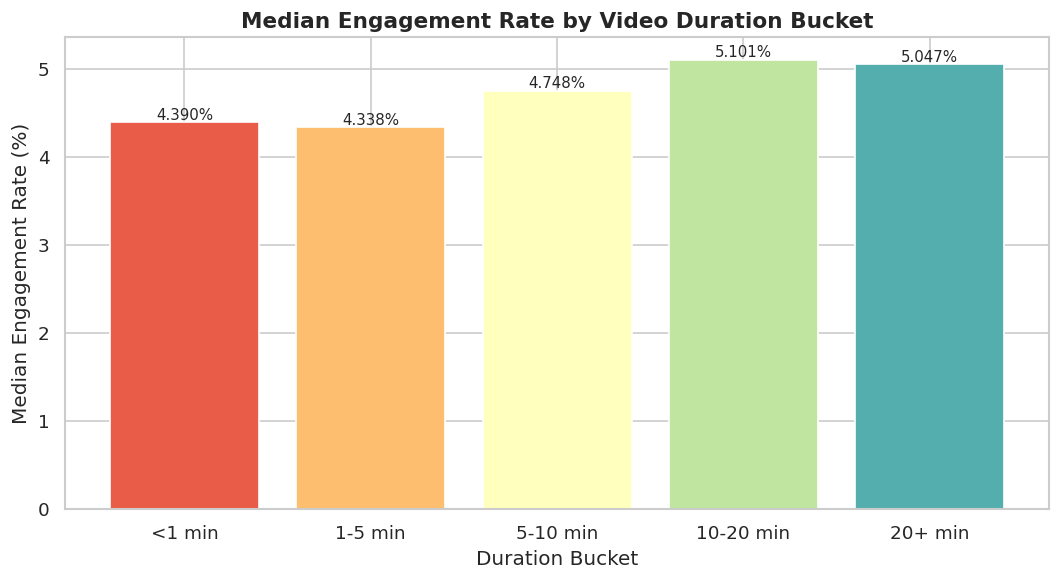

In [15]:
# --- Engagement Rate by Duration Bucket ---
eng_bucket = data.groupby('Duration_Bucket', observed=True)['Engagement_Rate'].median()
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(eng_bucket.index.astype(str), eng_bucket.values,
              color=sns.color_palette('Spectral', len(eng_bucket)))
ax.set_title("Median Engagement Rate by Video Duration Bucket", fontsize=13, fontweight='bold')
ax.set_xlabel("Duration Bucket"); ax.set_ylabel("Median Engagement Rate (%)")
for bar in bars:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f"{bar.get_height():.3f}%", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_eng_bucket.png', bbox_inches='tight')
plt.show()

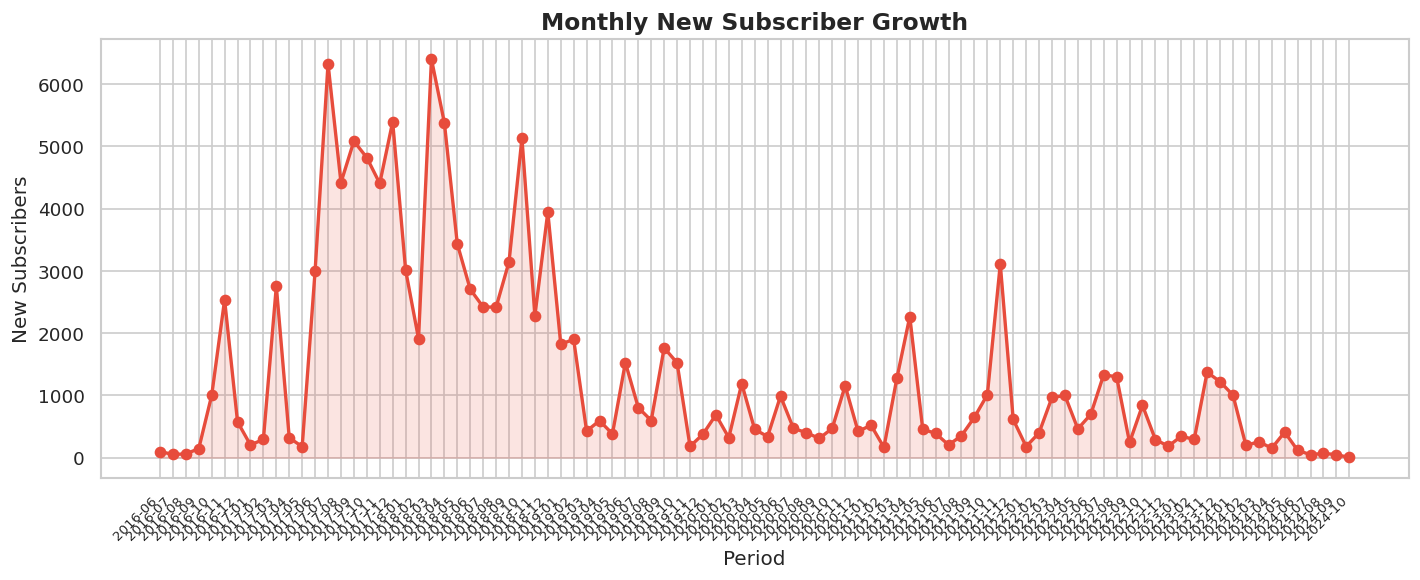

In [16]:
# --- Subscriber Growth Trend ---
if 'Year' in data.columns and 'Month' in data.columns:
    monthly = data.groupby(['Year','Month'])['New Subscribers'].sum().reset_index()
    monthly['Period'] = monthly['Year'].astype(str) + '-' + monthly['Month'].astype(str).str.zfill(2)
    monthly.sort_values('Period', inplace=True)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly['Period'], monthly['New Subscribers'], marker='o', color='#e74c3c', linewidth=2)
    ax.fill_between(range(len(monthly)), monthly['New Subscribers'], alpha=0.15, color='#e74c3c')
    ax.set_xticks(range(len(monthly)))
    ax.set_xticklabels(monthly['Period'], rotation=45, ha='right', fontsize=8)
    ax.set_title("Monthly New Subscriber Growth", fontsize=14, fontweight='bold')
    ax.set_xlabel("Period"); ax.set_ylabel("New Subscribers")
    plt.tight_layout()
    plt.savefig('/home/claude/fig_subs_trend.png', bbox_inches='tight')
    plt.show()

## Step 7 — Predictive Model: Estimate Revenue

In [17]:
features = ['Views', 'Subscribers', 'Likes', 'Shares', 'New Comments',
            'Engagement_Rate', 'CTR_Score', 'Average View Percentage (%)',
            'Watch Time (hours)', 'Ad Impressions']
target = 'Estimated Revenue (USD)'

model_df = data[features + [target]].dropna()
X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")
print(f"Feature matrix shape: {X.shape}")

Train size: 291 | Test size: 73
Feature matrix shape: (364, 10)


In [18]:
model = RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f"{'='*40}")
print(f"  Model Evaluation Metrics")
print(f"{'='*40}")
print(f"  Mean Squared Error  : {mse:.4f}")
print(f"  Root MSE (RMSE)     : {rmse:.4f}")
print(f"  R-squared Score     : {r2:.4f}")
print(f"{'='*40}")
print(f"  ✅ Model explains {r2*100:.1f}% of revenue variance")

  Model Evaluation Metrics
  Mean Squared Error  : 36.5397
  Root MSE (RMSE)     : 6.0448
  R-squared Score     : 0.5803
  ✅ Model explains 58.0% of revenue variance


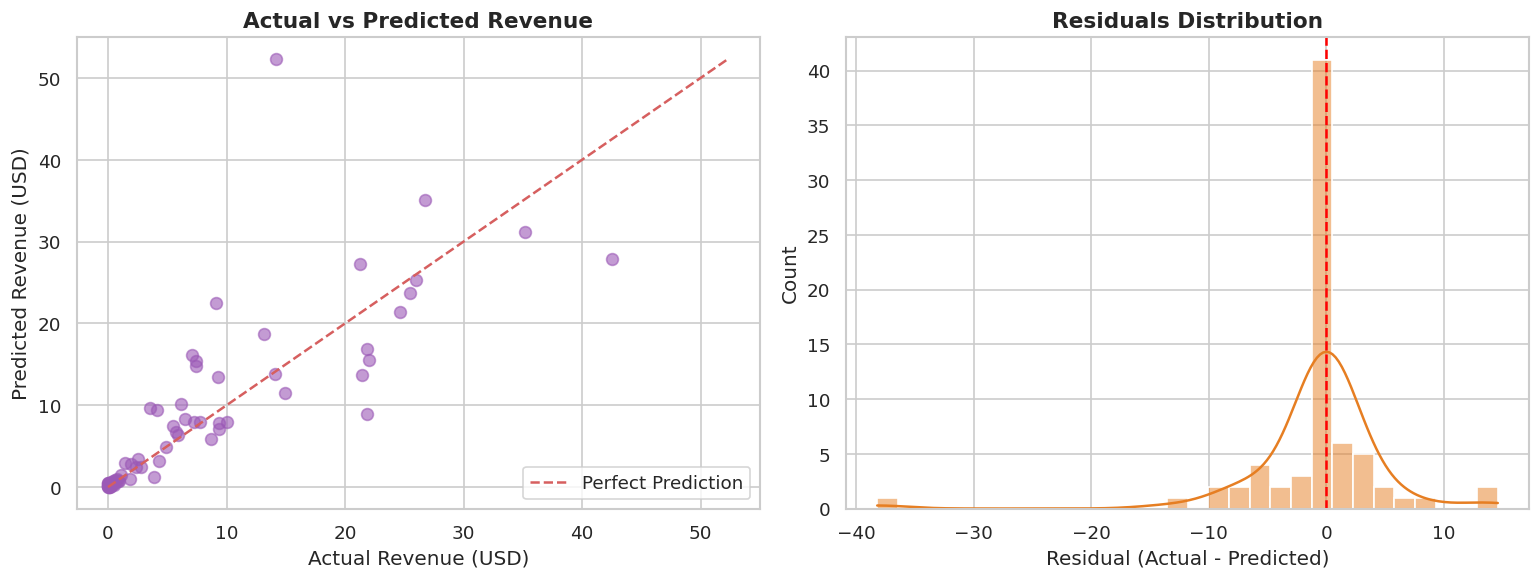

In [19]:
# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.6, color='#9b59b6', s=50)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_title("Actual vs Predicted Revenue", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Actual Revenue (USD)"); axes[0].set_ylabel("Predicted Revenue (USD)")
axes[0].legend()

residuals = y_test - y_pred
sns.histplot(residuals, kde=True, ax=axes[1], color='#e67e22', bins=30)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Residuals Distribution", fontsize=13, fontweight='bold')
axes[1].set_xlabel("Residual (Actual - Predicted)")

plt.tight_layout()
plt.savefig('/home/claude/fig_model.png', bbox_inches='tight')
plt.show()

## Step 8 — Insights & Feature Importance

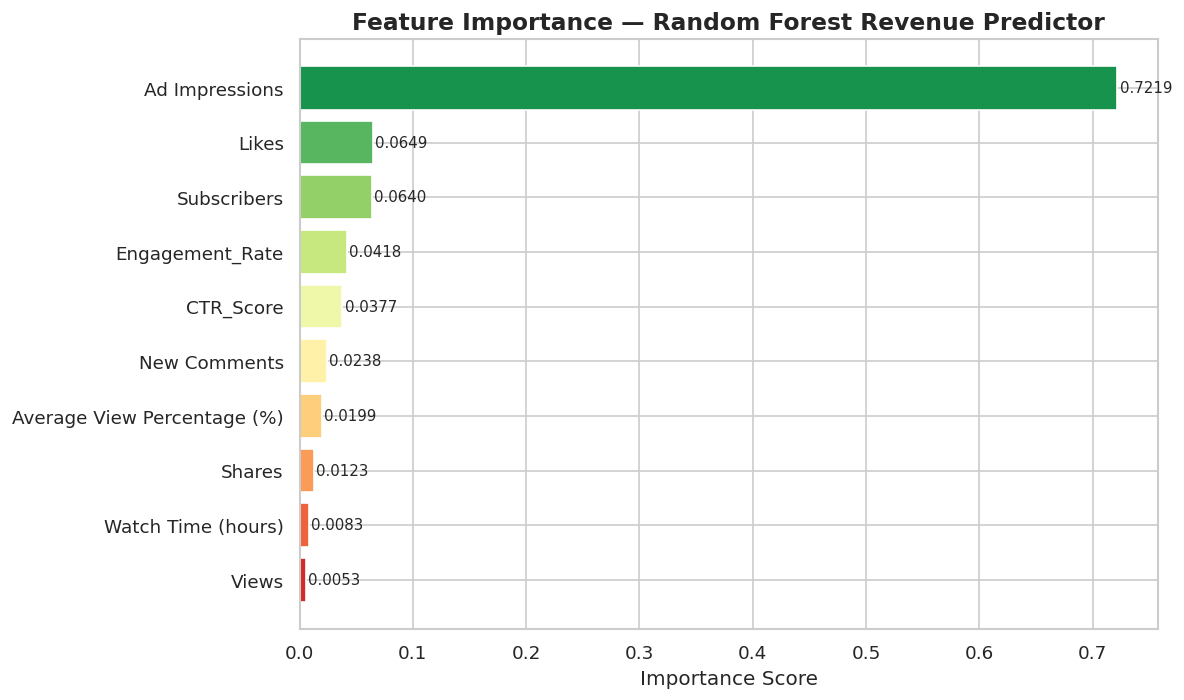

                    Feature  Importance
             Ad Impressions    0.721905
                      Likes    0.064884
                Subscribers    0.064030
            Engagement_Rate    0.041812
                  CTR_Score    0.037740
               New Comments    0.023798
Average View Percentage (%)    0.019897
                     Shares    0.012329
         Watch Time (hours)    0.008308
                      Views    0.005297


In [20]:
importances = model.feature_importances_
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
palette = sns.color_palette('RdYlGn', len(fi_df))[::-1]
bars = ax.barh(fi_df['Feature'], fi_df['Importance'], color=palette)
ax.set_title("Feature Importance — Random Forest Revenue Predictor", fontsize=14, fontweight='bold')
ax.set_xlabel("Importance Score"); ax.invert_yaxis()
for bar, val in zip(bars, fi_df['Importance']):
    ax.text(bar.get_width()+0.002, bar.get_y()+bar.get_height()/2,
            f"{val:.4f}", va='center', fontsize=9)
plt.tight_layout()
plt.savefig('/home/claude/fig_importance.png', bbox_inches='tight')
plt.show()
print(fi_df.to_string(index=False))

## Step 9 — Deployment & Presentation Summary

In [21]:
print("=" * 60)
print("   YOUTUBE CHANNEL PERFORMANCE — KEY FINDINGS")
print("=" * 60)

# Top revenue driver
top_feat = fi_df.iloc[0]['Feature']
print(f"\n🏆 Top Revenue Driver: {top_feat}")
print(f"   Importance Score: {fi_df.iloc[0]['Importance']:.4f}")

# Best day to post
best_day = data.groupby('Day of Week')['Estimated Revenue (USD)'].mean().idxmax()
print(f"\n📅 Best Publishing Day: {best_day}")

# Average CTR
avg_ctr = data['Video Thumbnail CTR (%)'].mean()
print(f"\n🖼️  Avg Thumbnail CTR: {avg_ctr:.2f}%")

# High engagement threshold
high_eng = data[data['Engagement_Rate'] > data['Engagement_Rate'].quantile(0.75)]
print(f"\n💬 Top-quartile engagement: {len(high_eng)} videos")
print(f"   Avg Revenue (high-eng): ${high_eng['Estimated Revenue (USD)'].mean():.2f}")
print(f"   Avg Revenue (rest):     ${data.loc[~data.index.isin(high_eng.index), 'Estimated Revenue (USD)'].mean():.2f}")

print(f"\n📈 Model R² = {r2:.4f} → explains {r2*100:.1f}% of revenue variance")
print("\n✅ Recommendations:")
print("   1. Prioritise content with higher View counts & Watch Time.")
print(f"  2. Publish on {best_day} for maximum revenue potential.")
print("   3. Improve thumbnail CTR through A/B testing.")
print("   4. Boost engagement (likes/shares/comments) to lift CPM.")
print("   5. Extend video length into the 5-10 min sweet spot.")
print("=" * 60)

   YOUTUBE CHANNEL PERFORMANCE — KEY FINDINGS

🏆 Top Revenue Driver: Ad Impressions
   Importance Score: 0.7219

📅 Best Publishing Day: Thursday

🖼️  Avg Thumbnail CTR: 7.91%

💬 Top-quartile engagement: 91 videos
   Avg Revenue (high-eng): $10.79
   Avg Revenue (rest):     $8.21

📈 Model R² = 0.5803 → explains 58.0% of revenue variance

✅ Recommendations:
   1. Prioritise content with higher View counts & Watch Time.
  2. Publish on Thursday for maximum revenue potential.
   3. Improve thumbnail CTR through A/B testing.
   4. Boost engagement (likes/shares/comments) to lift CPM.
   5. Extend video length into the 5-10 min sweet spot.
